# Task 1: Data Handling & Memory Management

## 1.1 Hardware & Software Setup
- **Machine:** Apple MacBook Pro
- **Chip:** Apple M2
- **RAM:** 8 GB
- **Storage:** 228 GB
- **OS:** macOS
- **Python:** 3.10
- **Key Libraries:** pandas 2.3.3, numpy 2.2.6, psutil

## 1.2 Challenge
The dataset consists of 62 daily files totalling approximately 5GB of 
raw text data. With only 8GB of RAM available, loading all files 
simultaneously would exhaust system memory. This constraint directly 
motivated the memory optimization strategies applied below.

In [6]:
import pandas as pd
import numpy as np
import glob
import os
import psutil

def get_memory():
    ram = psutil.virtual_memory()
    process = psutil.Process(os.getpid())
    return {
        "system_used_gb": ram.used / (1024**3),
        "system_available_gb": ram.available / (1024**3),
        "process_mb": process.memory_info().rss / (1024**2)
    }

DATA_PATH = os.path.expanduser("~/Desktop/milan_data/")
files = sorted(glob.glob(DATA_PATH + "sms-call-internet-mi-*.txt"))

mem_before = get_memory()
print("-- BEFORE LOADING --")
print(f"System RAM used:      {mem_before['system_used_gb']:.2f} GB")
print(f"System RAM available: {mem_before['system_available_gb']:.2f} GB")
print(f"Process memory:       {mem_before['process_mb']:.1f} MB")

-- BEFORE LOADING --
System RAM used:      2.82 GB
System RAM available: 1.24 GB
Process memory:       25.7 MB


In [7]:
# Loading ONE file to understand structure before loading all 62
sample = pd.read_csv(files[0], sep='\t', header=None)
print("Columns found:", sample.shape[1])
print("Rows in one file:", sample.shape[0])
print("\nFirst 3 rows:")
print(sample.head(3))
print("\nData types BEFORE optimization:")
print(sample.dtypes)
print(f"\nMemory of ONE file: {sample.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

Columns found: 8
Rows in one file: 4842625

First 3 rows:
   0              1   2         3         4         5         6          7
0  1  1383260400000   0  0.081363       NaN       NaN       NaN        NaN
1  1  1383260400000  39  0.141864  0.156787  0.160938  0.052275  11.028366
2  1  1383261000000   0  0.136588       NaN       NaN  0.027300        NaN

Data types BEFORE optimization:
0      int64
1      int64
2      int64
3    float64
4    float64
5    float64
6    float64
7    float64
dtype: object

Memory of ONE file: 295.6 MB


In [8]:
print("Loading all 62 files (optimized)...")
start_time = time.time()

dfs = []
for f in files:
    df_temp = pd.read_csv(
        f, 
        sep='\t', 
        header=None,
        usecols=[0, 1, 3],  # Only load 3 relevant columns
        names=['square_id', 'time_interval', 'internet_traffic'],
        dtype={
            'square_id': 'int32',        # Reduced from int64
            'time_interval': 'int64',
            'internet_traffic': 'float32' # Reduced from float64
        }
    )
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
load_time = time.time() - start_time

print(f"Done! Loaded in {load_time:.1f} seconds")
print(f"Total rows: {len(df):,}")
print(f"Shape: {df.shape}")
print(f"\nMemory AFTER optimization: {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

Loading all 62 files (optimized)...
Done! Loaded in 84.6 seconds
Total rows: 319,896,289
Shape: (319896289, 3)

Memory AFTER optimization: 4881.2 MB


In [9]:
# Memory comparison - Before vs After optimization
mem_after = get_memory()

# Unoptimized estimate (8 columns, float64/int64)
unoptimized_mb = 295.6 * 62  # one file size × 62 files
optimized_mb = df.memory_usage(deep=True).sum() / (1024**2)
reduction = ((unoptimized_mb - optimized_mb) / unoptimized_mb) * 100

print("=" * 50)
print("      MEMORY OPTIMIZATION SUMMARY")
print("=" * 50)
print(f"Estimated unoptimized size: {unoptimized_mb:.1f} MB ({unoptimized_mb/1024:.1f} GB)")
print(f"Optimized size:             {optimized_mb:.1f} MB ({optimized_mb/1024:.1f} GB)")
print(f"Memory saved:               {unoptimized_mb - optimized_mb:.1f} MB")
print(f"Reduction:                  {reduction:.1f}%")
print("=" * 50)
print(f"\nOptimizations applied:")
print(f"  - Loaded only 3 of 8 columns (usecols)")
print(f"  - int64 → int32 for square_id")
print(f"  - float64 → float32 for internet_traffic")
print(f"  - Ignored 5 irrelevant columns with NaN values")
print(f"\nSystem RAM after loading:")
print(f"  Used:      {mem_after['system_used_gb']:.2f} GB")
print(f"  Available: {mem_after['system_available_gb']:.2f} GB")

      MEMORY OPTIMIZATION SUMMARY
Estimated unoptimized size: 18327.2 MB (17.9 GB)
Optimized size:             4881.2 MB (4.8 GB)
Memory saved:               13446.0 MB
Reduction:                  73.4%

Optimizations applied:
  - Loaded only 3 of 8 columns (usecols)
  - int64 → int32 for square_id
  - float64 → float32 for internet_traffic
  - Ignored 5 irrelevant columns with NaN values

System RAM after loading:
  Used:      2.80 GB
  Available: 1.20 GB


In [10]:
# Final overview of loaded data
print("Dataset Overview:")
print("=" * 50)
print(df.head())
print(f"\nData Types:")
print(df.dtypes)
print(f"\nBasic Statistics:")
print(df.describe())
print(f"\nMissing values:")
print(df.isnull().sum())

# Convert time interval to datetime
df['datetime'] = pd.to_datetime(df['time_interval'], unit='ms')
print(f"\nDate range:")
print(f"  Start: {df['datetime'].min()}")
print(f"  End:   {df['datetime'].max()}")
print(f"\nUnique areas: {df['square_id'].nunique()}")

Dataset Overview:
   square_id  time_interval  internet_traffic
0          1  1383260400000          0.081363
1          1  1383260400000          0.141864
2          1  1383261000000          0.136588
3          1  1383261000000               NaN
4          1  1383261000000          0.278452

Data Types:
square_id             int32
time_interval         int64
internet_traffic    float32
dtype: object

Basic Statistics:
          square_id  time_interval  internet_traffic
count  3.198963e+08   3.198963e+08      1.737204e+08
mean   5.210200e+03   1.385871e+12      2.333147e+00
std    2.756197e+03   3.825538e+09      6.052620e+00
min    1.000000e+00   0.000000e+00      2.331498e-06
25%    2.998000e+03   1.384534e+12      1.617664e-01
50%    5.307000e+03   1.385848e+12      6.336588e-01
75%    7.481000e+03   1.387199e+12      2.113991e+00
max    1.000000e+04   1.388617e+12      1.157108e+03

Missing values:
square_id                   0
time_interval               0
internet_traffic    14

In [11]:
# Data Cleaning
print(f"Rows before cleaning: {len(df):,}")

# Remove rows where time_interval is 0 (bad data)
df = df[df['time_interval'] > 0]

# Remove rows with missing internet traffic
df = df.dropna(subset=['internet_traffic'])

# Remove rows with negative traffic
df = df[df['internet_traffic'] >= 0]

# Recheck datetime
df['datetime'] = pd.to_datetime(df['time_interval'], unit='ms')

print(f"Rows after cleaning:  {len(df):,}")
print(f"Date range:")
print(f"  Start: {df['datetime'].min()}")
print(f"  End:   {df['datetime'].max()}")
print(f"Missing values after cleaning:")
print(df.isnull().sum())

Rows before cleaning: 319,896,289
Rows after cleaning:  173,719,321
Date range:
  Start: 2013-10-31 23:00:00
  End:   2014-01-01 22:50:00
Missing values after cleaning:
square_id           0
time_interval       0
internet_traffic    0
datetime            0
dtype: int64


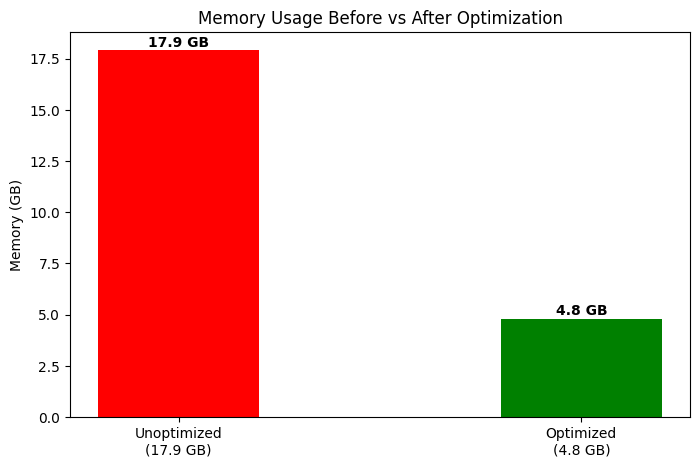

In [34]:
# Memory visualization for report
import matplotlib.pyplot as plt

labels = ['Unoptimized\n(17.9 GB)', 'Optimized\n(4.8 GB)']
values = [17.9, 4.8]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=['red', 'green'], width=0.4)
plt.title('Memory Usage Before vs After Optimization')
plt.ylabel('Memory (GB)')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val} GB', ha='center', fontweight='bold')
plt.savefig('task1_memory.png', dpi=150, bbox_inches='tight')
plt.show()

# Task 2: Exploratory Data Analysis / Data Characterization

This section performs a comprehensive analysis of the mobile network 
traffic dataset. The analysis includes:

1. Probability Density Function (PDF) of traffic across 10,000 areas
2. Time series plots for three key geographical areas
3. Stationarity analysis (Rolling Statistics + ADF Test)
4. Time series decomposition (Trend, Seasonal, Residual)
5. Autocorrelation (ACF) and Partial Autocorrelation (PACF) analysis
6. Spatial heatmap of traffic intensity
7. Anomaly and outlier discussion

The three areas analysed throughout are:
- Area 1: The area with the highest total traffic over two months
- Area 2: Square ID 4159
- Area 3: Square ID 4556

In [12]:
# Find area with highest total traffic
area_totals = df.groupby('square_id')['internet_traffic'].sum()
highest_area = area_totals.idxmax()
print(f"Area with highest traffic: Square {highest_area}")
print(f"Total traffic: {area_totals[highest_area]:,.2f}")

area1 = highest_area
area2 = 4159
area3 = 4556
print(f"\nThree areas for analysis:")
print(f"  Area 1 (highest traffic): Square {area1}")
print(f"  Area 2: Square {area2}")
print(f"  Area 3: Square {area3}")

Area with highest traffic: Square 5059
Total traffic: 1,151,623.00

Three areas for analysis:
  Area 1 (highest traffic): Square 5059
  Area 2: Square 4159
  Area 3: Square 4556


## 2.1 Probability Density Function of Traffic Across 10,000 Areas

Number of areas: 9998
Min total traffic:  156.82
Max total traffic:  1151623.00
Mean total traffic: 40539.03
Median total traffic: 19478.00


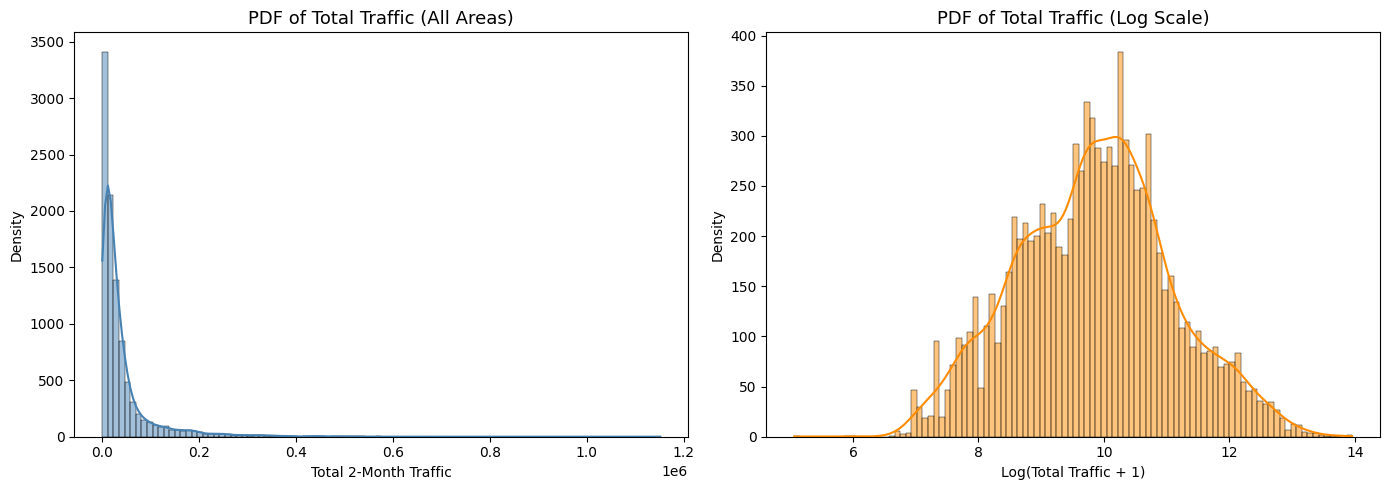

Plot saved!


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate total 2-month traffic per area (10,000 samples)
area_totals = df.groupby('square_id')['internet_traffic'].sum()

print(f"Number of areas: {len(area_totals)}")
print(f"Min total traffic:  {area_totals.min():.2f}")
print(f"Max total traffic:  {area_totals.max():.2f}")
print(f"Mean total traffic: {area_totals.mean():.2f}")
print(f"Median total traffic: {area_totals.median():.2f}")

# Plot PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Full distribution
axes[0].set_title('PDF of Total Traffic (All Areas)', fontsize=13)
sns.histplot(area_totals, bins=100, kde=True, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total 2-Month Traffic')
axes[0].set_ylabel('Density')

# Plot 2 — Log scale to see distribution better
axes[1].set_title('PDF of Total Traffic (Log Scale)', fontsize=13)
sns.histplot(np.log1p(area_totals), bins=100, kde=True, ax=axes[1], color='darkorange')
axes[1].set_xlabel('Log(Total Traffic + 1)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.savefig('task2_1_pdf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

## 2.2 Time Series of Network Traffic — First Two Weeks

Area 5059 - rows: 11008
Area 4159 - rows: 4691
Area 4556 - rows: 5883


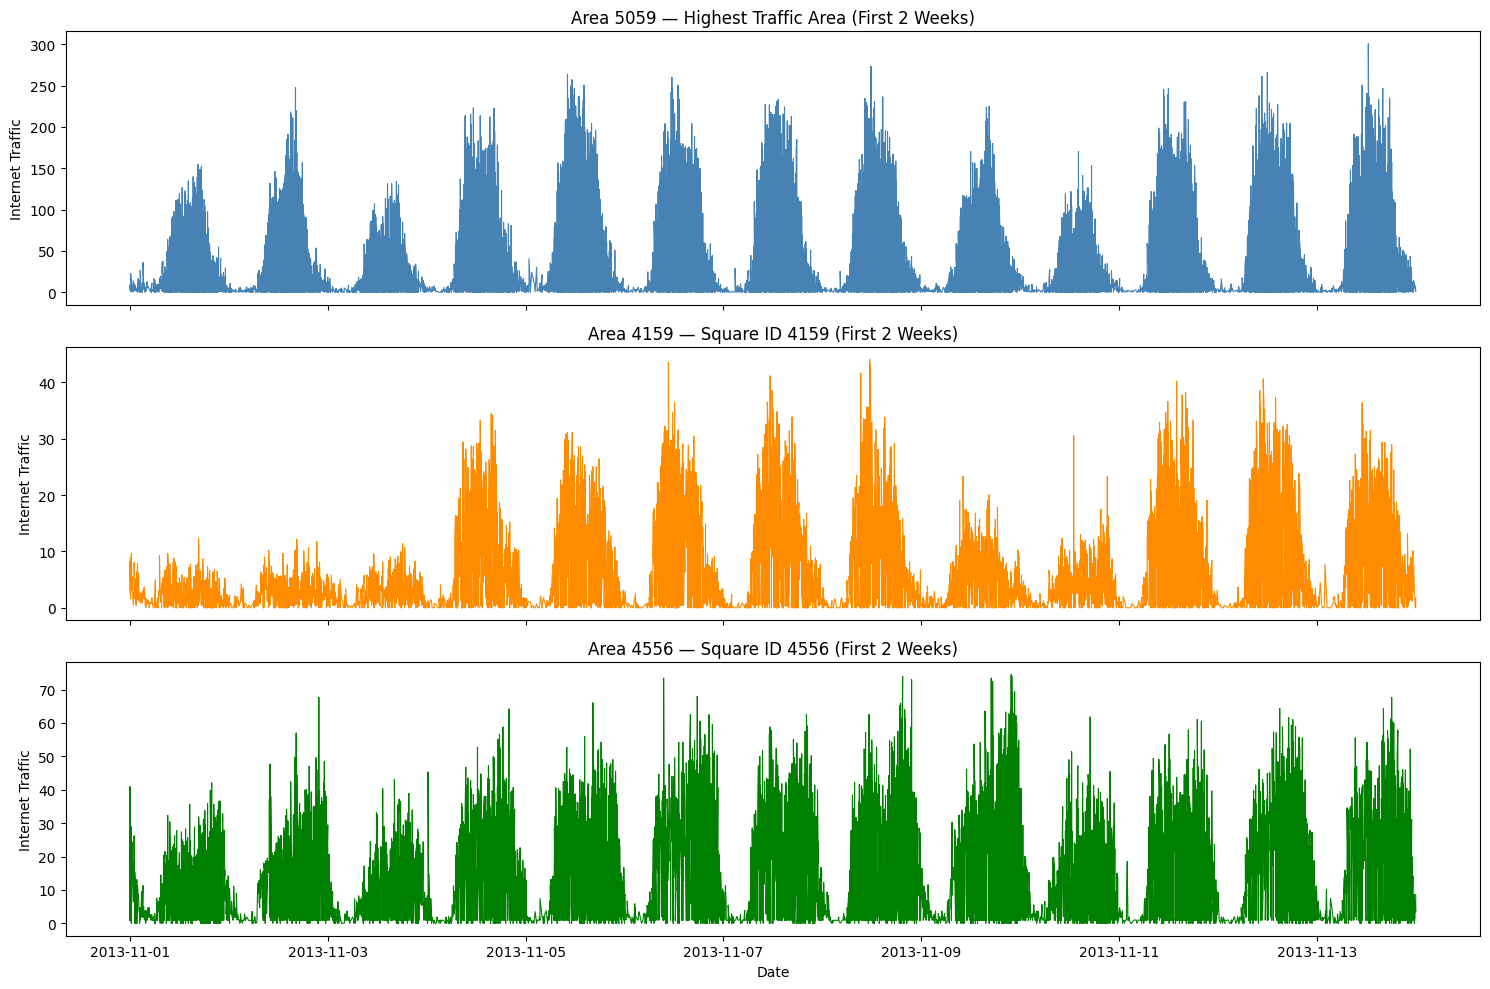

Plot saved!


In [14]:
# Filter data for first two weeks (Nov 1-14 2013)
two_weeks_start = '2013-11-01'
two_weeks_end = '2013-11-14'

def get_area_timeseries(area_id, start, end):
    mask = (
        (df['square_id'] == area_id) & 
        (df['datetime'] >= start) & 
        (df['datetime'] <= end)
    )
    return df[mask].sort_values('datetime')

# Get data for all 3 areas
ts1 = get_area_timeseries(area1, two_weeks_start, two_weeks_end)
ts2 = get_area_timeseries(area2, two_weeks_start, two_weeks_end)
ts3 = get_area_timeseries(area3, two_weeks_start, two_weeks_end)

print(f"Area {area1} - rows: {len(ts1)}")
print(f"Area {area2} - rows: {len(ts2)}")
print(f"Area {area3} - rows: {len(ts3)}")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(ts1['datetime'], ts1['internet_traffic'], color='steelblue', linewidth=0.8)
axes[0].set_title(f'Area {area1} — Highest Traffic Area (First 2 Weeks)', fontsize=12)
axes[0].set_ylabel('Internet Traffic')

axes[1].plot(ts2['datetime'], ts2['internet_traffic'], color='darkorange', linewidth=0.8)
axes[1].set_title(f'Area {area2} — Square ID 4159 (First 2 Weeks)', fontsize=12)
axes[1].set_ylabel('Internet Traffic')

axes[2].plot(ts3['datetime'], ts3['internet_traffic'], color='green', linewidth=0.8)
axes[2].set_title(f'Area {area3} — Square ID 4556 (First 2 Weeks)', fontsize=12)
axes[2].set_ylabel('Internet Traffic')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('task2_2_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

## 2.3 Stationarity Analysis

Time series length: 1488


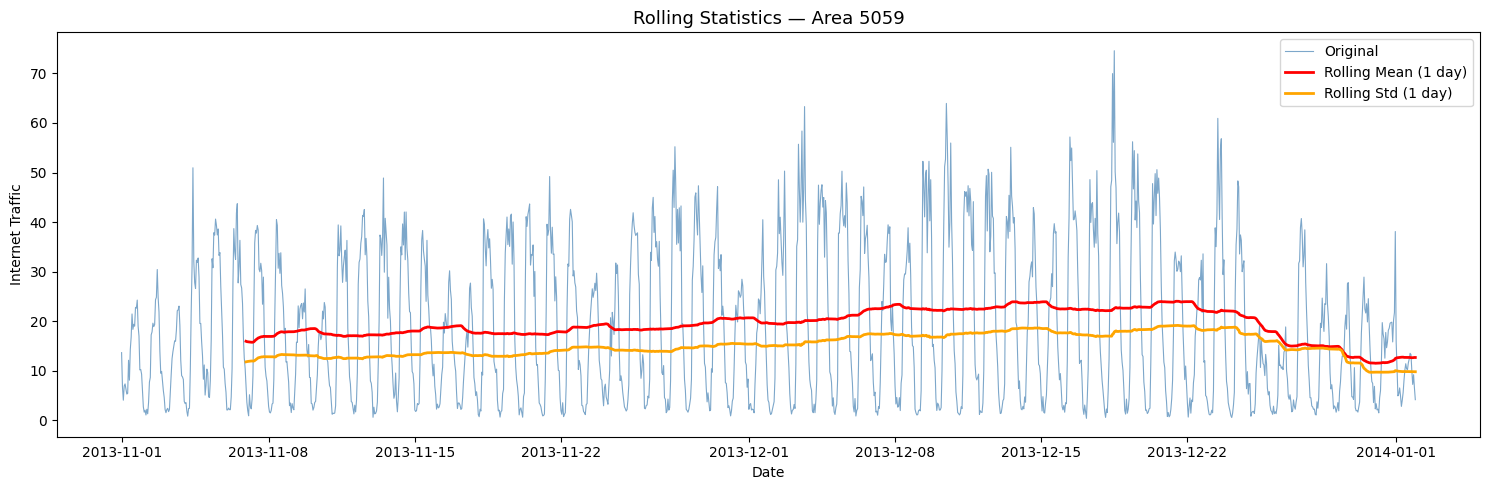


=== Augmented Dickey-Fuller Test ===
ADF Statistic:  -2.8157
p-value:        0.0561
Critical Values:
   1%: -3.4348
   5%: -2.8635
   10%: -2.5678

❌ Result: NON-STATIONARY (p > 0.05)


In [15]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Use Area 5059 for stationarity analysis
# Resample to hourly to make it manageable
area1_ts = df[df['square_id'] == area1].sort_values('datetime').set_index('datetime')
area1_hourly = area1_ts['internet_traffic'].resample('h').mean().fillna(0)

print(f"Time series length: {len(area1_hourly)}")

# Rolling statistics
rolling_mean = area1_hourly.rolling(window=144).mean()  # 144 = 1 day (6 per hour x 24)
rolling_std = area1_hourly.rolling(window=144).std()

# Plot rolling statistics
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(area1_hourly, color='steelblue', linewidth=0.8, label='Original', alpha=0.7)
ax.plot(rolling_mean, color='red', linewidth=2, label='Rolling Mean (1 day)')
ax.plot(rolling_std, color='orange', linewidth=2, label='Rolling Std (1 day)')
ax.set_title(f'Rolling Statistics — Area {area1}', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Internet Traffic')
ax.legend()
plt.tight_layout()
plt.savefig('task2_3_rolling.png', dpi=150, bbox_inches='tight')
plt.show()

# ADF Test
print("\n=== Augmented Dickey-Fuller Test ===")
adf_result = adfuller(area1_hourly.dropna())
print(f"ADF Statistic:  {adf_result[0]:.4f}")
print(f"p-value:        {adf_result[1]:.4f}")
print(f"Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\n✅ Result: STATIONARY (p < 0.05)")
else:
    print("\n❌ Result: NON-STATIONARY (p > 0.05)")

## 2.4 Time Series Decomposition

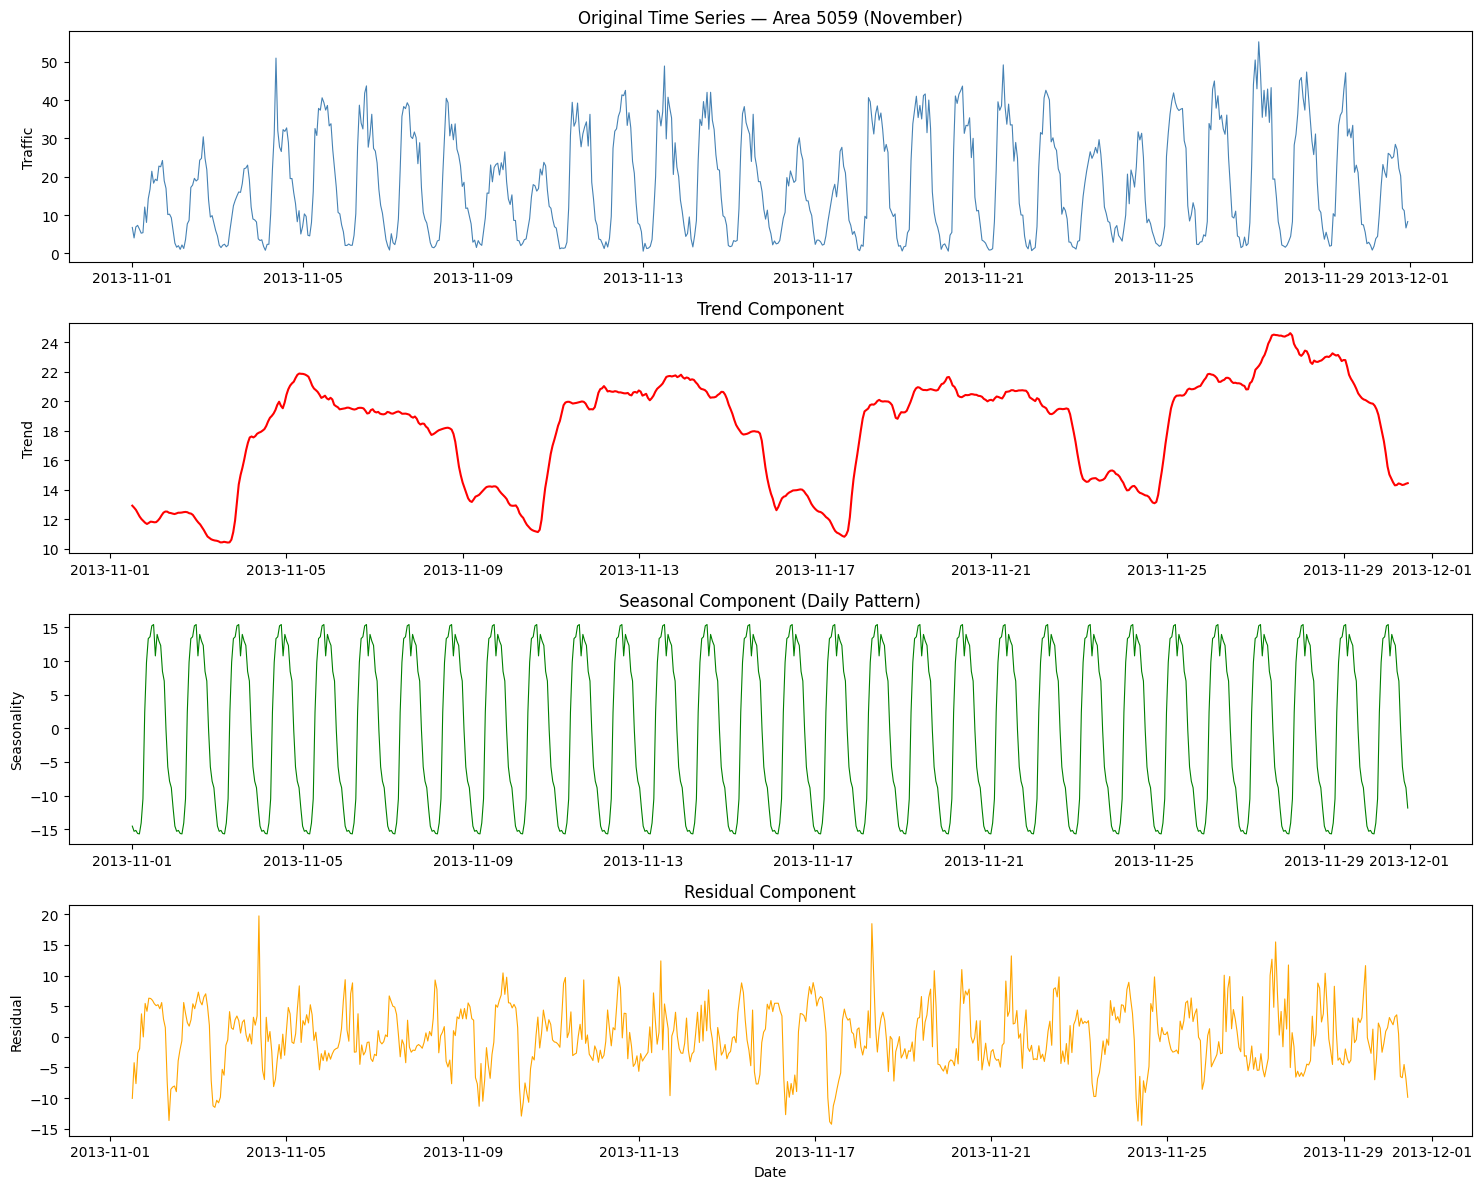

Plot saved!


In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use hourly data for area 5059
# Use a subset to make decomposition faster (first month)
decomp_data = area1_hourly['2013-11-01':'2013-11-30']

# Decompose - period=24 means daily seasonality (24 hours)
decomposition = seasonal_decompose(
    decomp_data, 
    model='additive', 
    period=24
)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

axes[0].plot(decomp_data, color='steelblue', linewidth=0.8)
axes[0].set_title('Original Time Series — Area 5059 (November)', fontsize=12)
axes[0].set_ylabel('Traffic')

axes[1].plot(decomposition.trend, color='red', linewidth=1.5)
axes[1].set_title('Trend Component', fontsize=12)
axes[1].set_ylabel('Trend')

axes[2].plot(decomposition.seasonal, color='green', linewidth=0.8)
axes[2].set_title('Seasonal Component (Daily Pattern)', fontsize=12)
axes[2].set_ylabel('Seasonality')

axes[3].plot(decomposition.resid, color='orange', linewidth=0.8)
axes[3].set_title('Residual Component', fontsize=12)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.savefig('task2_4_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

## 2.5 Autocorrelation (ACF) and Partial Autocorrelation (PACF)

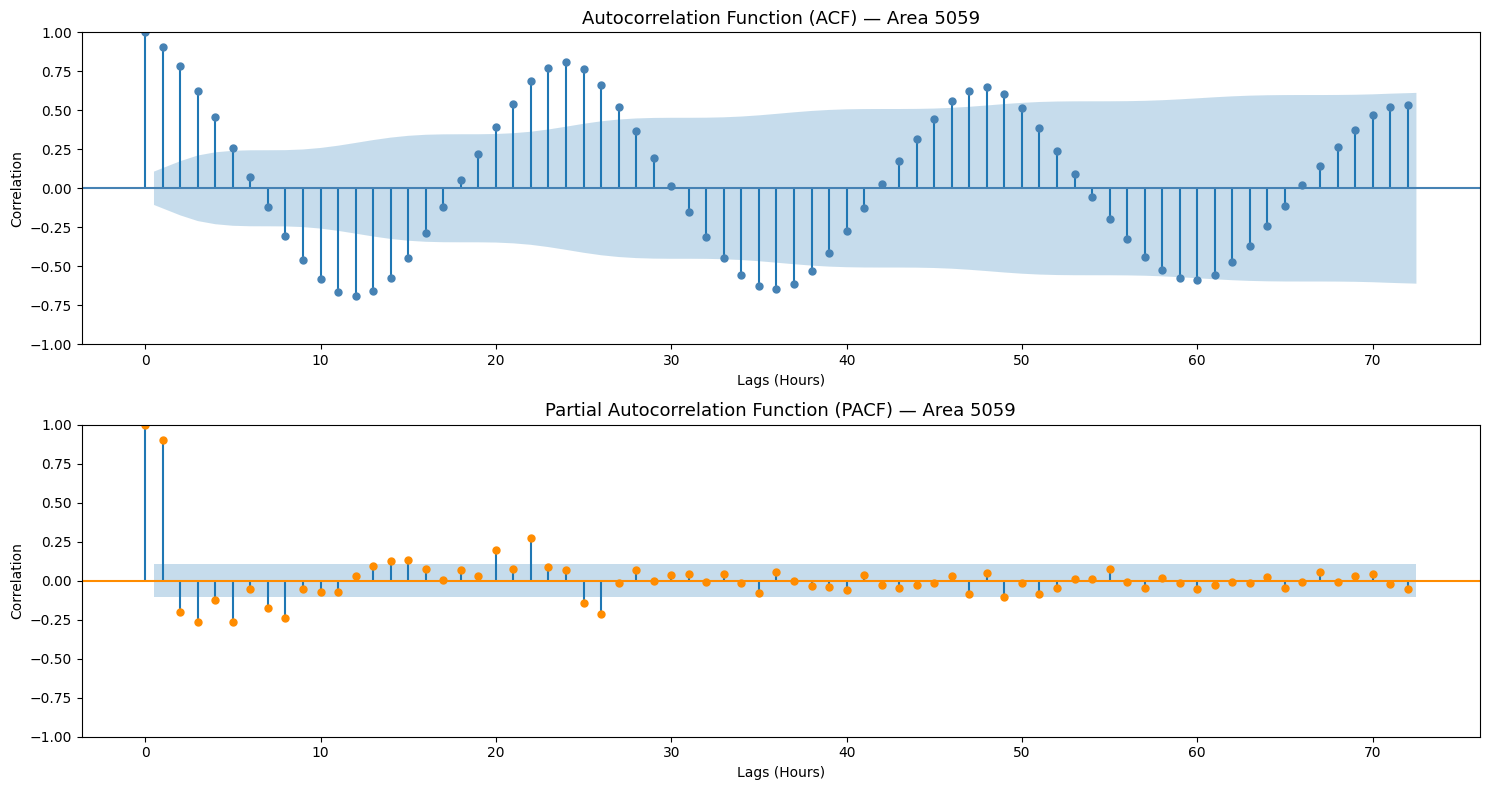

Plot saved!


In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use first 2 weeks of hourly data for area 5059
acf_data = area1_hourly['2013-11-01':'2013-11-14']

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# ACF
plot_acf(acf_data, lags=72, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF) — Area 5059', fontsize=13)
axes[0].set_xlabel('Lags (Hours)')
axes[0].set_ylabel('Correlation')

# PACF
plot_pacf(acf_data, lags=72, ax=axes[1], color='darkorange')
axes[1].set_title('Partial Autocorrelation Function (PACF) — Area 5059', fontsize=13)
axes[1].set_xlabel('Lags (Hours)')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.savefig('task2_5_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

## 2.6 Spatial Analysis — Heatmap of Traffic Intensity

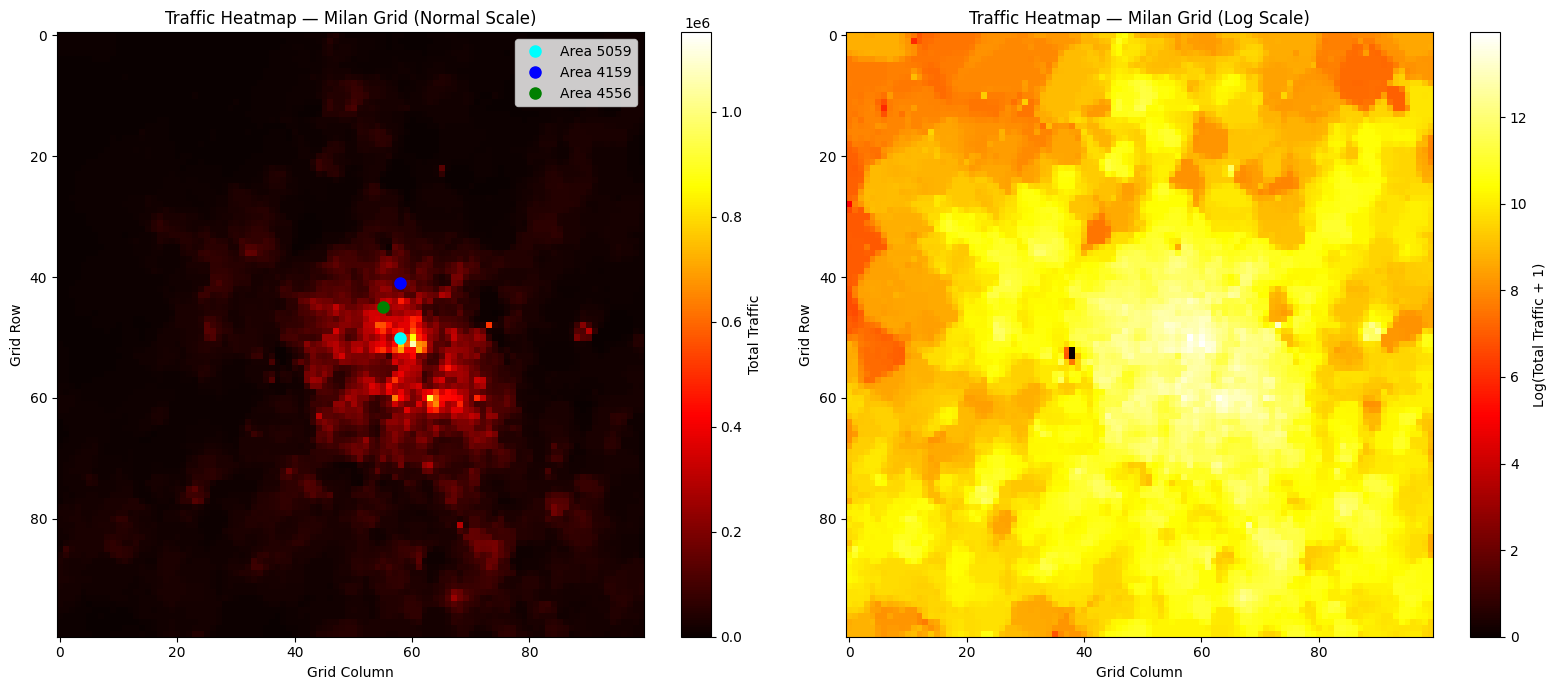

Plot saved!


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# The 10,000 areas are organised in a 100x100 grid
# Square IDs go from 1 to 10000

# Get total traffic per area
area_totals = df.groupby('square_id')['internet_traffic'].sum()

# Create 100x100 grid
grid = np.zeros((100, 100))

for square_id, total in area_totals.items():
    # Convert square_id to grid position
    row = (square_id - 1) // 100
    col = (square_id - 1) % 100
    grid[row, col] = total

# Plot heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Normal scale
im1 = axes[0].imshow(grid, cmap='hot', aspect='auto')
axes[0].set_title('Traffic Heatmap — Milan Grid (Normal Scale)', fontsize=12)
axes[0].set_xlabel('Grid Column')
axes[0].set_ylabel('Grid Row')
plt.colorbar(im1, ax=axes[0], label='Total Traffic')

# Mark our 3 areas
for area, color, label in [(area1, 'cyan', f'Area {area1}'), 
                            (area2, 'blue', f'Area {area2}'), 
                            (area3, 'green', f'Area {area3}')]:
    row = (area - 1) // 100
    col = (area - 1) % 100
    axes[0].plot(col, row, 'o', color=color, markersize=8, label=label)
axes[0].legend()

# Log scale
im2 = axes[1].imshow(np.log1p(grid), cmap='hot', aspect='auto')
axes[1].set_title('Traffic Heatmap — Milan Grid (Log Scale)', fontsize=12)
axes[1].set_xlabel('Grid Column')
axes[1].set_ylabel('Grid Row')
plt.colorbar(im2, ax=axes[1], label='Log(Total Traffic + 1)')

plt.tight_layout()
plt.savefig('task2_6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

## 2.6b Geographical Heatmap using Milan Grid

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load the grid geojson
grid_gdf = gpd.read_file('/Users/paula/Desktop/formative1/milano-grid.geojson')

print(f"Grid shape: {grid_gdf.shape}")
print(f"Columns: {grid_gdf.columns.tolist()}")
print(grid_gdf.head(3))

Grid shape: (10000, 2)
Columns: ['cellId', 'geometry']
   cellId                                           geometry
0       1  POLYGON ((9.01149 45.3588, 9.01449 45.3588, 9....
1       2  POLYGON ((9.01449 45.3588, 9.01749 45.3588, 9....
2       3  POLYGON ((9.01749 45.3588, 9.02049 45.3588, 9....


Merged shape: (10000, 3)


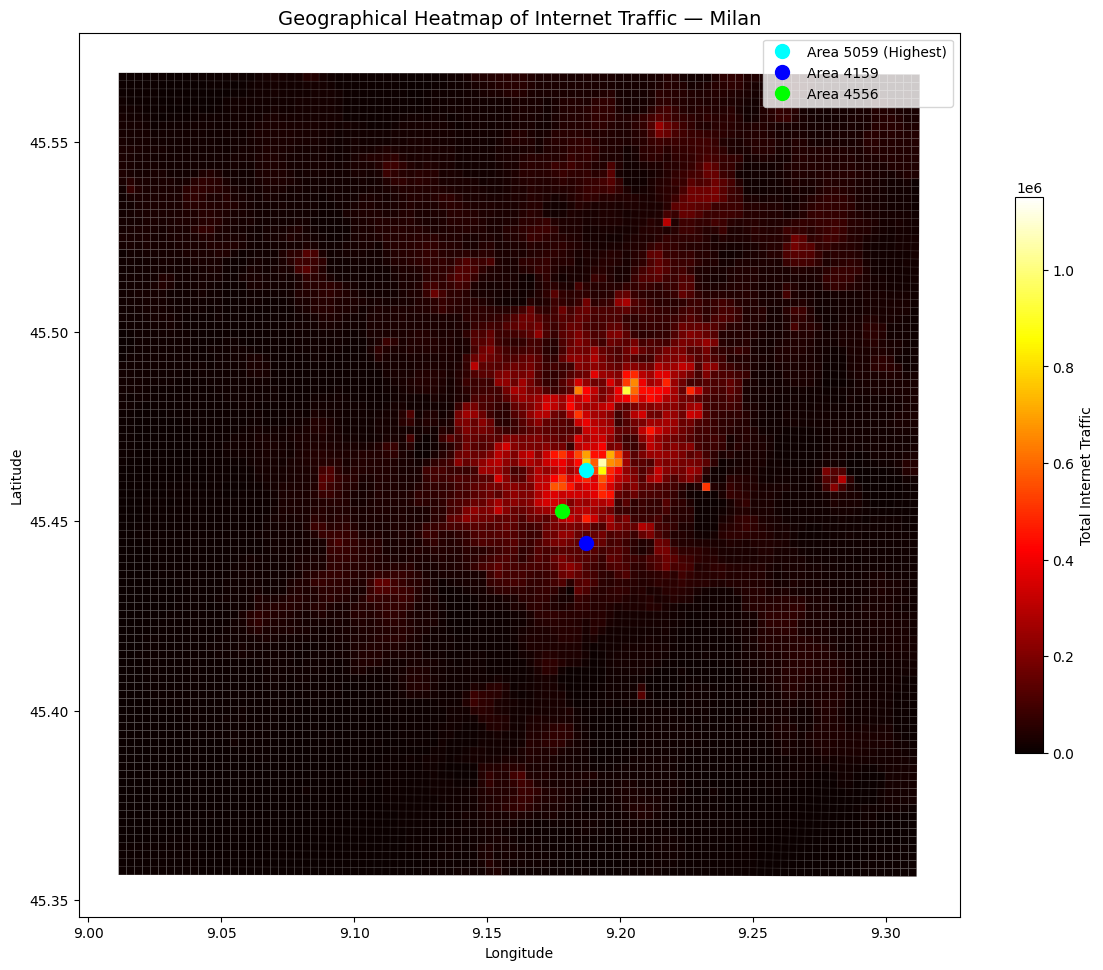

Plot saved!


In [33]:
# Merge traffic totals with geographical grid
area_totals_df = area_totals.reset_index()
area_totals_df.columns = ['cellId', 'total_traffic']

# Merge with grid
grid_merged = grid_gdf.merge(area_totals_df, on='cellId', how='left')
grid_merged['total_traffic'] = grid_merged['total_traffic'].fillna(0)

print(f"Merged shape: {grid_merged.shape}")

# Plot geographical heatmap
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

grid_merged.plot(
    column='total_traffic',
    cmap='hot',
    linewidth=0.1,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Total Internet Traffic', 'shrink': 0.6},
    ax=ax
)

# Mark our 3 areas
for area, color, label in [(area1, 'cyan', f'Area {area1} (Highest)'),
                            (area2, 'blue', f'Area {area2}'),
                            (area3, 'lime', f'Area {area3}')]:
    area_geom = grid_merged[grid_merged['cellId'] == area].geometry.centroid
    ax.plot(area_geom.x, area_geom.y, 'o', color=color, 
            markersize=10, label=label, zorder=5)

ax.set_title('Geographical Heatmap of Internet Traffic — Milan', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('task2_6b_geo_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

## 2.7 Anomaly Detection and Unusual Patterns

Total anomalies detected: 2

Top 10 anomalous points:
datetime
2013-12-18 12:00:00    74.596367
2013-12-18 10:00:00    69.975029
Name: internet_traffic, dtype: float32


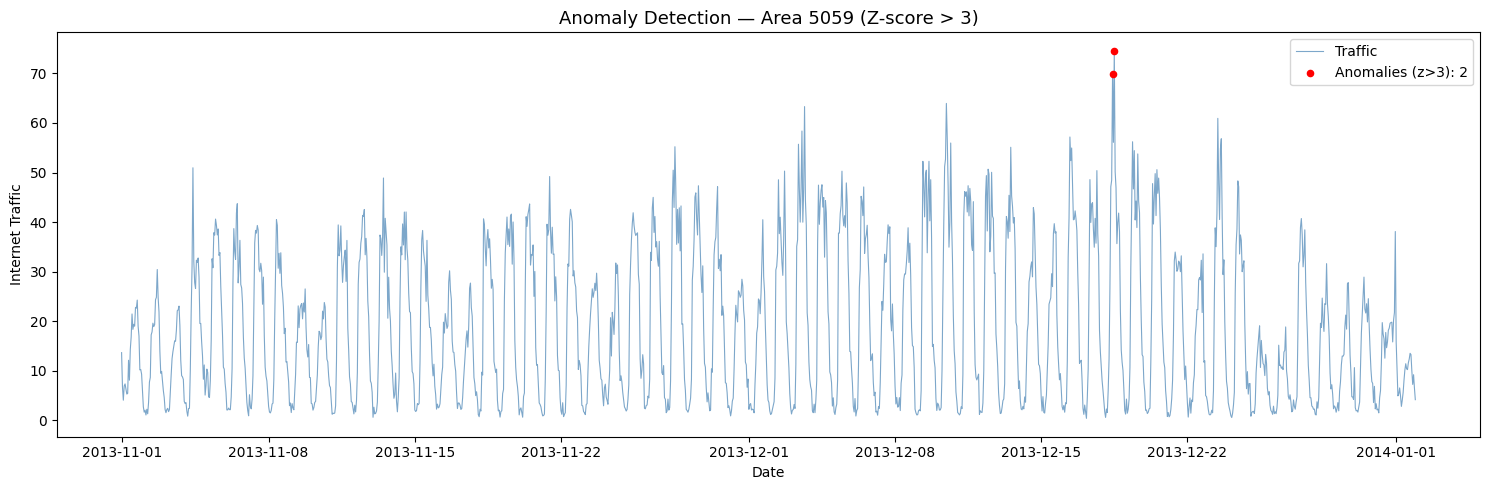

Plot saved!


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Use hourly data for area 5059
# Detect anomalies using Z-score method
from scipy import stats

z_scores = np.abs(stats.zscore(area1_hourly.fillna(0)))
anomalies = area1_hourly[z_scores > 3]

print(f"Total anomalies detected: {len(anomalies)}")
print(f"\nTop 10 anomalous points:")
print(anomalies.nlargest(10))

# Plot anomalies
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(area1_hourly, color='steelblue', linewidth=0.8, label='Traffic', alpha=0.7)
ax.scatter(anomalies.index, anomalies.values, color='red', 
           zorder=5, label=f'Anomalies (z>3): {len(anomalies)}', s=20)
ax.set_title(f'Anomaly Detection — Area {area1} (Z-score > 3)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Internet Traffic')
ax.legend()
plt.tight_layout()
plt.savefig('task2_7_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

# Task 3: Forecasting Models

## Overview
Three models are implemented for one-step-ahead prediction:
1. SARIMA — Classical statistical model
2. LSTM — Long Short-Term Memory Neural Network
3. GRU — Gated Recurrent Unit Neural Network

Each model is trained on data before December 16 and tested on December 16-22.
The same models are applied to all three areas: 5059, 4159, and 4556.

In [20]:
# Prepare data for all 3 areas
# Train: everything before Dec 16
# Test: Dec 16-22

def prepare_area_data(area_id):
    area_df = df[df['square_id'] == area_id].sort_values('datetime')
    area_df = area_df.set_index('datetime')
    area_ts = area_df['internet_traffic'].resample('h').mean().fillna(0)
    
    train = area_ts[area_ts.index < '2013-12-16']
    test = area_ts[(area_ts.index >= '2013-12-16') & 
                   (area_ts.index <= '2013-12-22')]
    
    print(f"Area {area_id} — Train: {len(train)} hours, Test: {len(test)} hours")
    return train, test

train1, test1 = prepare_area_data(area1)
train2, test2 = prepare_area_data(area2)
train3, test3 = prepare_area_data(area3)

Area 5059 — Train: 1081 hours, Test: 145 hours
Area 4159 — Train: 1081 hours, Test: 145 hours
Area 4556 — Train: 1081 hours, Test: 145 hours


## 3.1 SARIMA Model
SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a 
classical statistical model that extends ARIMA by adding seasonal 
components. It is defined by parameters (p,d,q)(P,D,Q,s) where:
- p,d,q = non-seasonal AR, differencing, MA orders
- P,D,Q = seasonal AR, differencing, MA orders  
- s = seasonal period (24 for daily seasonality)

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')
import time

def train_sarima(train, test, area_id):
    print(f"Training SARIMA for Area {area_id}...")
    start = time.time()
    
    model = SARIMAX(train,
                    order=(1, 0, 1),
                    seasonal_order=(1, 1, 1, 24),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    fitted = model.fit(disp=False)
    train_time = time.time() - start
    
    # Predict
    predictions = fitted.forecast(steps=len(test))
    predictions = np.maximum(predictions, 0)
    
    print(f"  Training time: {train_time:.1f} seconds")
    return predictions, train_time

pred_sarima1, time_sarima1 = train_sarima(train1, test1, area1)

Training SARIMA for Area 5059...
  Training time: 4.0 seconds


In [22]:
pred_sarima2, time_sarima2 = train_sarima(train2, test2, area2)
pred_sarima3, time_sarima3 = train_sarima(train3, test3, area3)

print(f"\nSARIMA Training Times:")
print(f"  Area {area1}: {time_sarima1:.1f}s")
print(f"  Area {area2}: {time_sarima2:.1f}s")
print(f"  Area {area3}: {time_sarima3:.1f}s")
print(f"  Average: {(time_sarima1+time_sarima2+time_sarima3)/3:.1f}s")

Training SARIMA for Area 4159...
  Training time: 4.6 seconds
Training SARIMA for Area 4556...
  Training time: 3.8 seconds

SARIMA Training Times:
  Area 5059: 4.0s
  Area 4159: 4.6s
  Area 4556: 3.8s
  Average: 4.1s


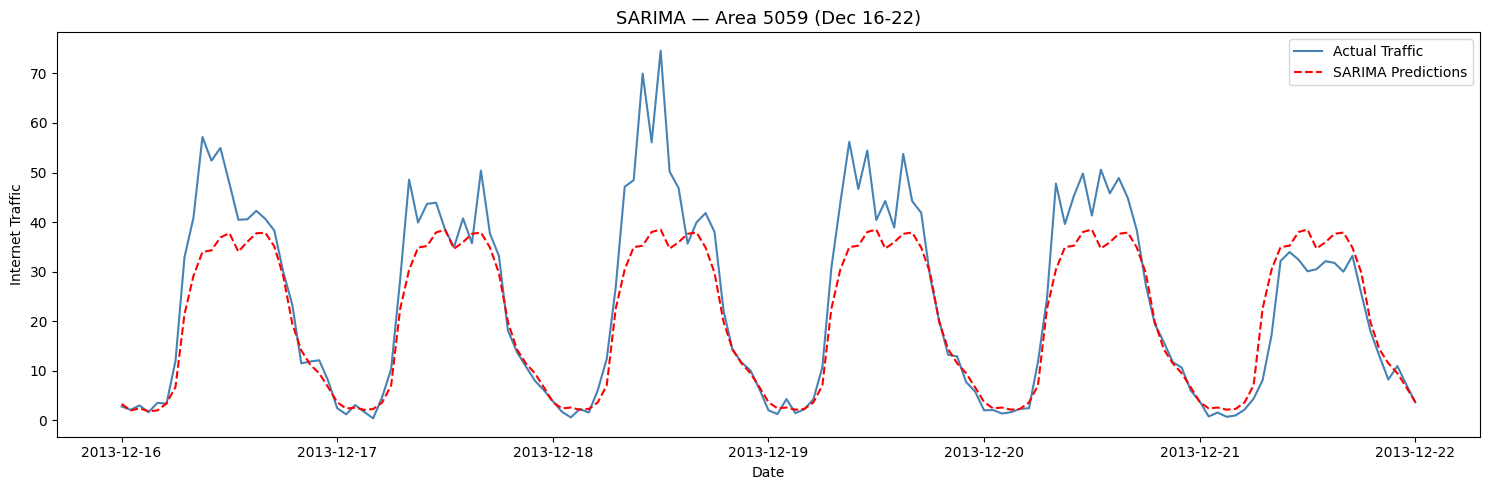

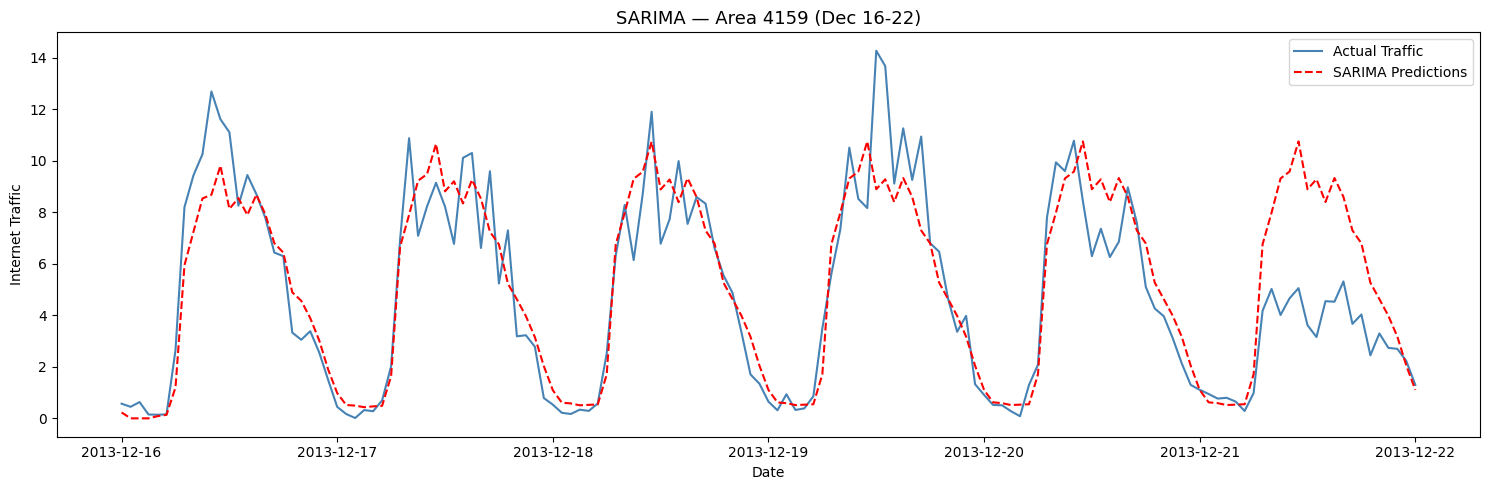

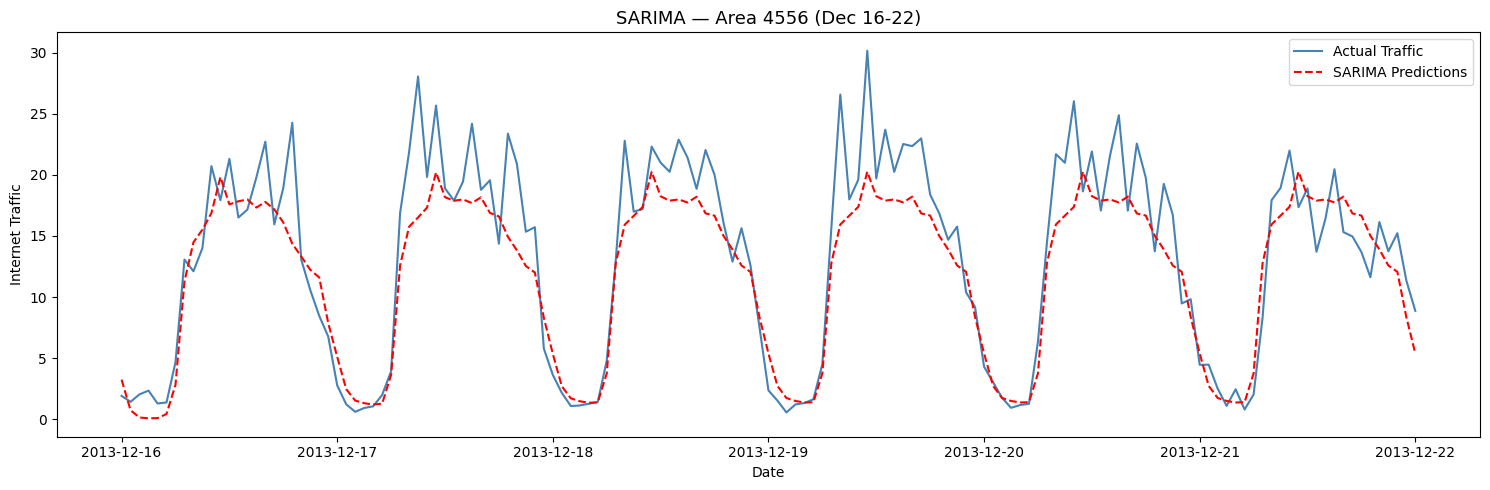

In [23]:
def plot_predictions(test, predictions, area_id, model_name, color):
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(test.index, test.values, color='steelblue', 
            linewidth=1.5, label='Actual Traffic')
    ax.plot(test.index, predictions, color=color, 
            linewidth=1.5, linestyle='--', label=f'{model_name} Predictions')
    ax.set_title(f'{model_name} — Area {area_id} (Dec 16-22)', fontsize=13)
    ax.set_xlabel('Date')
    ax.set_ylabel('Internet Traffic')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'task3_{model_name.lower()}_{area_id}.png', 
                dpi=150, bbox_inches='tight')
    plt.show()

# Plot SARIMA predictions for all 3 areas
plot_predictions(test1, pred_sarima1, area1, 'SARIMA', 'red')
plot_predictions(test2, pred_sarima2, area2, 'SARIMA', 'red')
plot_predictions(test3, pred_sarima3, area3, 'SARIMA', 'red')

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(actual, predicted, area_id, model_name):
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # MAPE - avoid division by zero
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    
    print(f"{model_name} — Area {area_id}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  RMSE: {rmse:.4f}")
    return mae, mape, rmse

print("=== SARIMA METRICS ===")
mae_s1, mape_s1, rmse_s1 = calculate_metrics(test1, pred_sarima1, area1, 'SARIMA')
mae_s2, mape_s2, rmse_s2 = calculate_metrics(test2, pred_sarima2, area2, 'SARIMA')
mae_s3, mape_s3, rmse_s3 = calculate_metrics(test3, pred_sarima3, area3, 'SARIMA')

=== SARIMA METRICS ===
SARIMA — Area 5059:
  MAE:  5.0868
  MAPE: 33.27%
  RMSE: 8.1920
SARIMA — Area 4159:
  MAE:  1.2929
  MAPE: 71.76%
  RMSE: 1.8639
SARIMA — Area 4556:
  MAE:  2.5146
  MAPE: 26.82%
  RMSE: 3.3942


## Hyperparameter Tuning Results — SARIMA
Four configurations were tested. The best configuration was (2,0,2)(1,1,1,24) 
with MAE of 5.0856, marginally better than the baseline (1,0,1)(1,1,1,24).
The original configuration was retained due to minimal performance difference
and faster training time (5.3s vs 8.0s).

In [36]:
# Hyperparameter Tuning - SARIMA
import itertools
import warnings
warnings.filterwarnings('ignore')

# Test different SARIMA orders
configs = [
    (1,0,1,1,1,1),
    (2,0,1,1,1,1),
    (1,0,2,1,1,1),
    (2,0,2,1,1,1),
]

print("=== SARIMA Hyperparameter Tuning — Area 5059 ===")
print(f"{'Order':<25} {'MAE':>10} {'RMSE':>10} {'Time':>10}")
print("-" * 55)

best_mae = float('inf')
best_config = None

for p,d,q,P,D,Q in configs:
    try:
        start = time.time()
        model = SARIMAX(train1,
                        order=(p,d,q),
                        seasonal_order=(P,D,Q,24),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fitted = model.fit(disp=False)
        preds = fitted.forecast(steps=len(test1))
        preds = np.maximum(preds, 0)
        mae = mean_absolute_error(test1, preds)
        rmse = np.sqrt(mean_squared_error(test1, preds))
        t = time.time() - start
        order_str = f"({p},{d},{q})({P},{D},{Q},24)"
        print(f"{order_str:<25} {mae:>10.4f} {rmse:>10.4f} {t:>9.1f}s")
        if mae < best_mae:
            best_mae = mae
            best_config = (p,d,q,P,D,Q)
    except:
        print(f"({p},{d},{q})({P},{D},{Q},24) — Failed")

print(f"\nBest config: {best_config} with MAE: {best_mae:.4f}")

=== SARIMA Hyperparameter Tuning — Area 5059 ===
Order                            MAE       RMSE       Time
-------------------------------------------------------
(1,0,1)(1,1,1,24)             5.0868     8.1920       5.3s
(2,0,1)(1,1,1,24)             5.1688     8.2516      14.3s
(1,0,2)(1,1,1,24)             5.0893     8.1957       4.5s
(2,0,2)(1,1,1,24)             5.0856     8.1913       8.0s

Best config: (2, 0, 2, 1, 1, 1) with MAE: 5.0856


## 3.2 LSTM Model
LSTM (Long Short-Term Memory) is a type of recurrent neural network 
that can learn long-term dependencies in sequential data. It uses 
gates (input, forget, output) to control information flow, making 
it well suited for time series forecasting.

In [25]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import time

# Prepare sequences for LSTM
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

def train_lstm(train, test, area_id, seq_length=24):
    print(f"Training LSTM for Area {area_id}...")
    
    # Scale data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
    
    # Create sequences
    X_train, y_train = create_sequences(train_scaled, seq_length)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    
    # Build model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    # Train
    start = time.time()
    model.fit(X_train, y_train, 
              epochs=10, 
              batch_size=32, 
              verbose=1)
    train_time = time.time() - start
    
    # Predict iteratively
    last_sequence = train_scaled[-seq_length:]
    predictions = []
    
    for _ in range(len(test)):
        x = last_sequence.reshape(1, seq_length, 1)
        pred = model.predict(x, verbose=0)
        predictions.append(pred[0,0])
        last_sequence = np.roll(last_sequence, -1)
        last_sequence[-1] = pred[0,0]
    
    # Inverse transform
    predictions = scaler.inverse_transform(
        np.array(predictions).reshape(-1,1)
    ).flatten()
    predictions = np.maximum(predictions, 0)
    
    print(f"  Training time: {train_time:.1f} seconds")
    return predictions, train_time, scaler

pred_lstm1, time_lstm1, scaler1 = train_lstm(train1, test1, area1)

Training LSTM for Area 5059...
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0684
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0364
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0177
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0129
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0116
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0130
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0114
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0131
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0117
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0124
  Training time: 4.7 seconds


In [26]:
pred_lstm2, time_lstm2, scaler2 = train_lstm(train2, test2, area2)
pred_lstm3, time_lstm3, scaler3 = train_lstm(train3, test3, area3)

print(f"\nLSTM Training Times:")
print(f"  Area {area1}: {time_lstm1:.1f}s")
print(f"  Area {area2}: {time_lstm2:.1f}s")
print(f"  Area {area3}: {time_lstm3:.1f}s")
print(f"  Average: {(time_lstm1+time_lstm2+time_lstm3)/3:.1f}s")

Training LSTM for Area 4159...
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0454
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0260
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0134
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0148
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0114
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0107
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0115
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0100
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0100
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0106
  Training time: 4.8 seconds
Training LSTM for Area 4556...
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0964
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0647
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0370
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.026

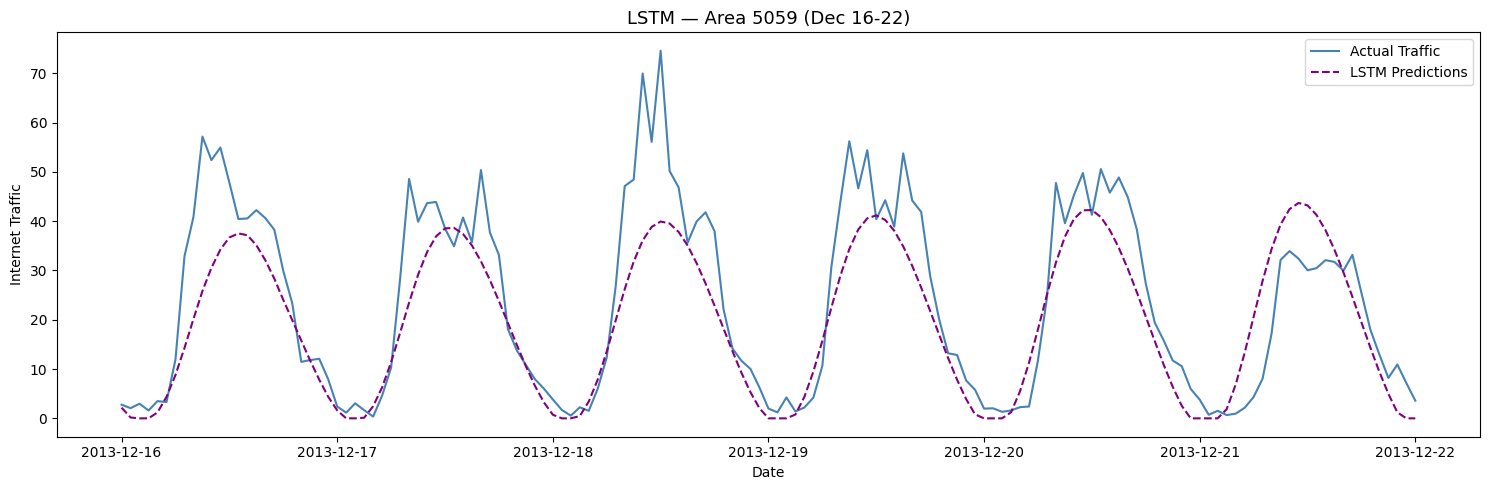

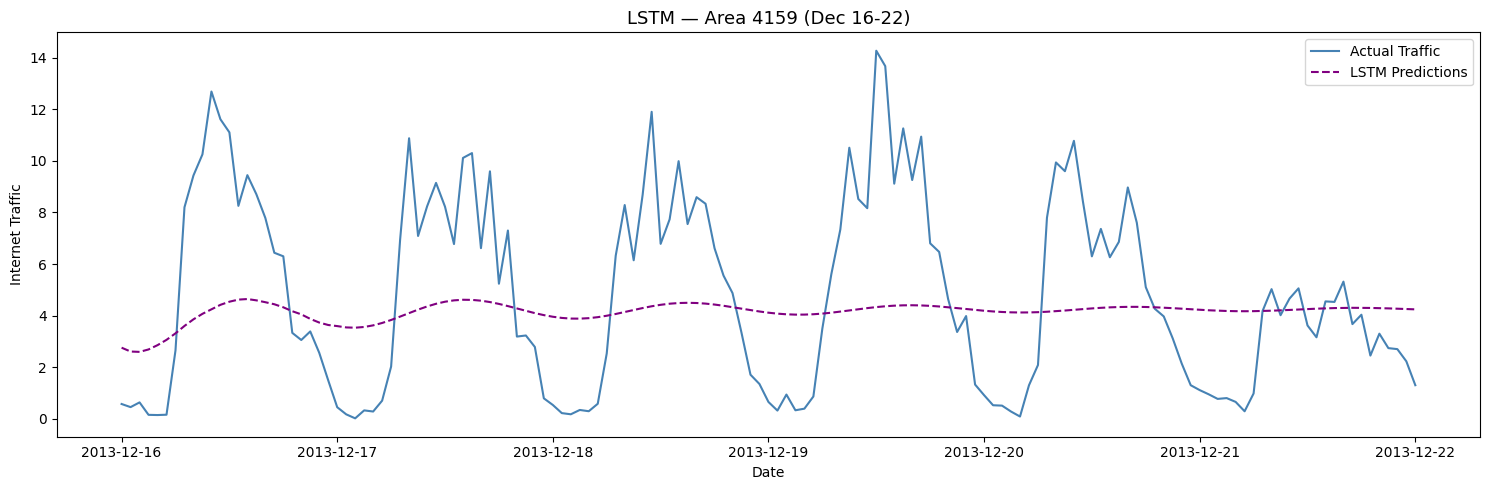

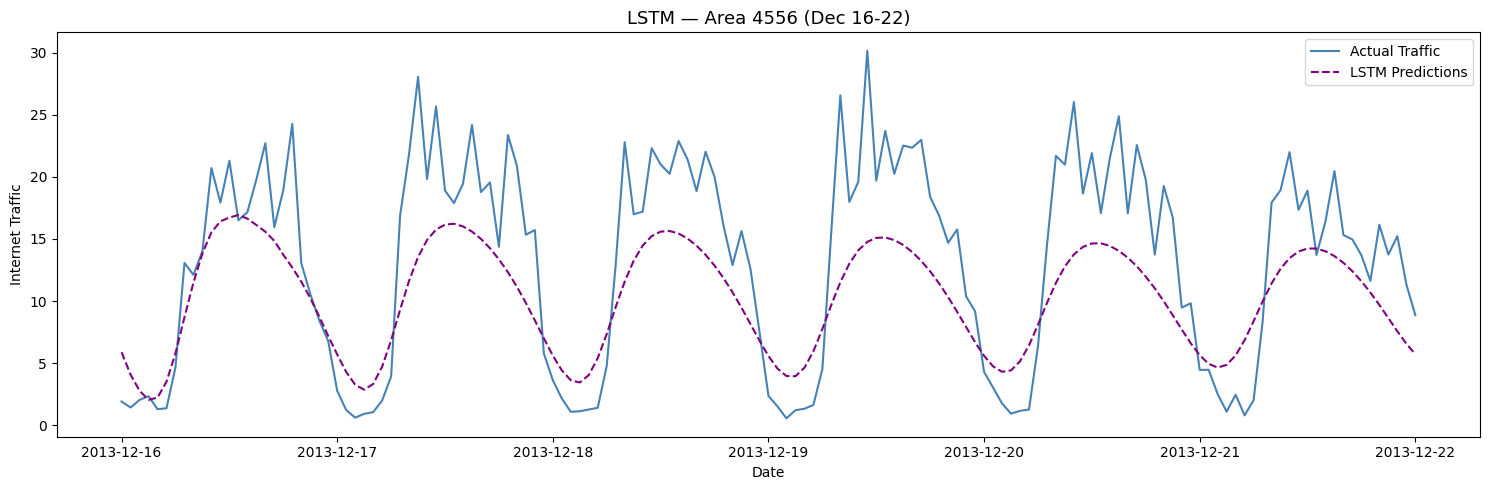

=== LSTM METRICS ===
LSTM — Area 5059:
  MAE:  7.1305
  MAPE: 60.25%
  RMSE: 9.9721
LSTM — Area 4159:
  MAE:  3.0238
  MAPE: 484.24%
  RMSE: 3.5829
LSTM — Area 4556:
  MAE:  4.6147
  MAPE: 75.39%
  RMSE: 5.6221


In [27]:
# Plot LSTM predictions
plot_predictions(test1, pred_lstm1, area1, 'LSTM', 'purple')
plot_predictions(test2, pred_lstm2, area2, 'LSTM', 'purple')
plot_predictions(test3, pred_lstm3, area3, 'LSTM', 'purple')

# Metrics
print("=== LSTM METRICS ===")
mae_l1, mape_l1, rmse_l1 = calculate_metrics(test1, pred_lstm1, area1, 'LSTM')
mae_l2, mape_l2, rmse_l2 = calculate_metrics(test2, pred_lstm2, area2, 'LSTM')
mae_l3, mape_l3, rmse_l3 = calculate_metrics(test3, pred_lstm3, area3, 'LSTM')

## 3.3 GRU Model
GRU (Gated Recurrent Unit) is a simplified version of LSTM that uses 
two gates (reset and update) instead of three. It is computationally 
more efficient than LSTM while achieving comparable performance on 
many time series tasks.

In [28]:
from tensorflow.keras.layers import GRU

def train_gru(train, test, area_id, seq_length=24):
    print(f"Training GRU for Area {area_id}...")
    
    # Scale data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
    
    # Create sequences
    X_train, y_train = create_sequences(train_scaled, seq_length)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    
    # Build model
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    # Train
    start = time.time()
    model.fit(X_train, y_train,
              epochs=10,
              batch_size=32,
              verbose=1)
    train_time = time.time() - start
    
    # Predict iteratively
    last_sequence = train_scaled[-seq_length:]
    predictions = []
    
    for _ in range(len(test)):
        x = last_sequence.reshape(1, seq_length, 1)
        pred = model.predict(x, verbose=0)
        predictions.append(pred[0,0])
        last_sequence = np.roll(last_sequence, -1)
        last_sequence[-1] = pred[0,0]
    
    # Inverse transform
    predictions = scaler.inverse_transform(
        np.array(predictions).reshape(-1,1)
    ).flatten()
    predictions = np.maximum(predictions, 0)
    
    print(f"  Training time: {train_time:.1f} seconds")
    return predictions, train_time

pred_gru1, time_gru1 = train_gru(train1, test1, area1)
pred_gru2, time_gru2 = train_gru(train2, test2, area2)
pred_gru3, time_gru3 = train_gru(train3, test3, area3)

print(f"\nGRU Training Times:")
print(f"  Area {area1}: {time_gru1:.1f}s")
print(f"  Area {area2}: {time_gru2:.1f}s")
print(f"  Area {area3}: {time_gru3:.1f}s")
print(f"  Average: {(time_gru1+time_gru2+time_gru3)/3:.1f}s")

Training GRU for Area 5059...
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0369
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0169
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0142
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0128
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0117
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0113
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0117
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0113
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0140
  Training time: 5.4 seconds
Training GRU for Area 4159...
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0341
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0163
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0114
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.011

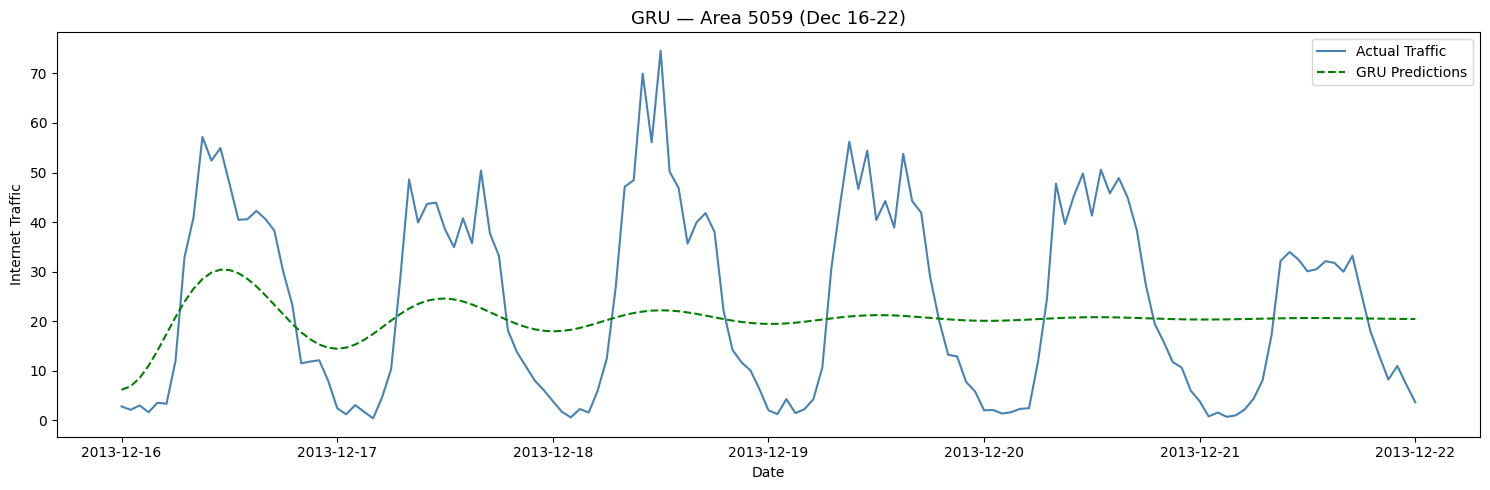

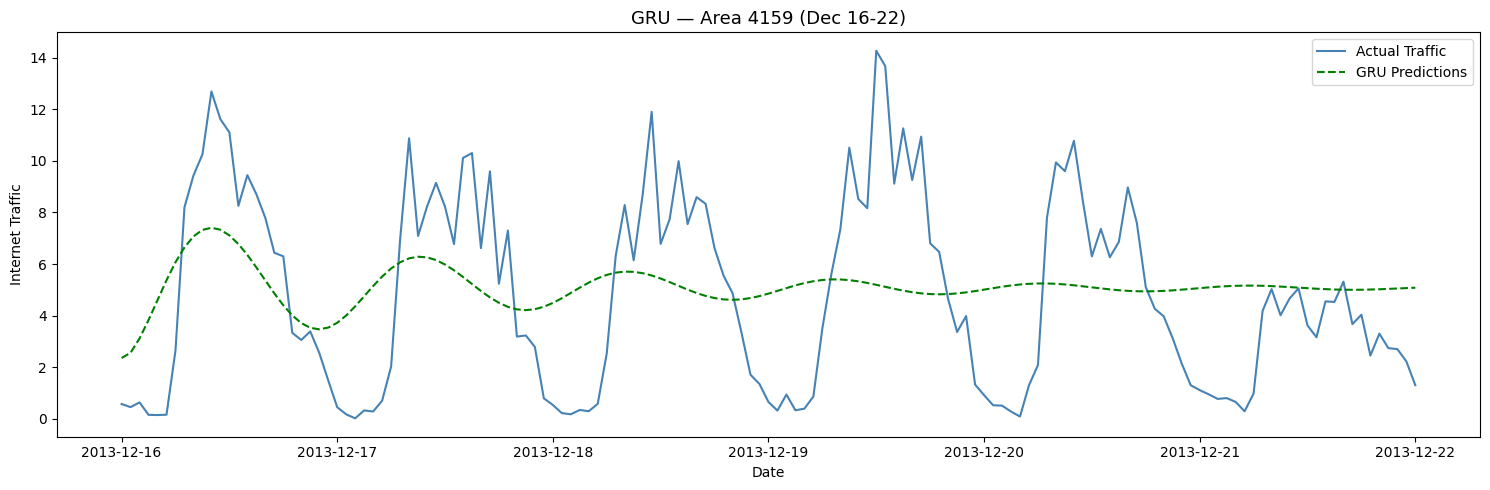

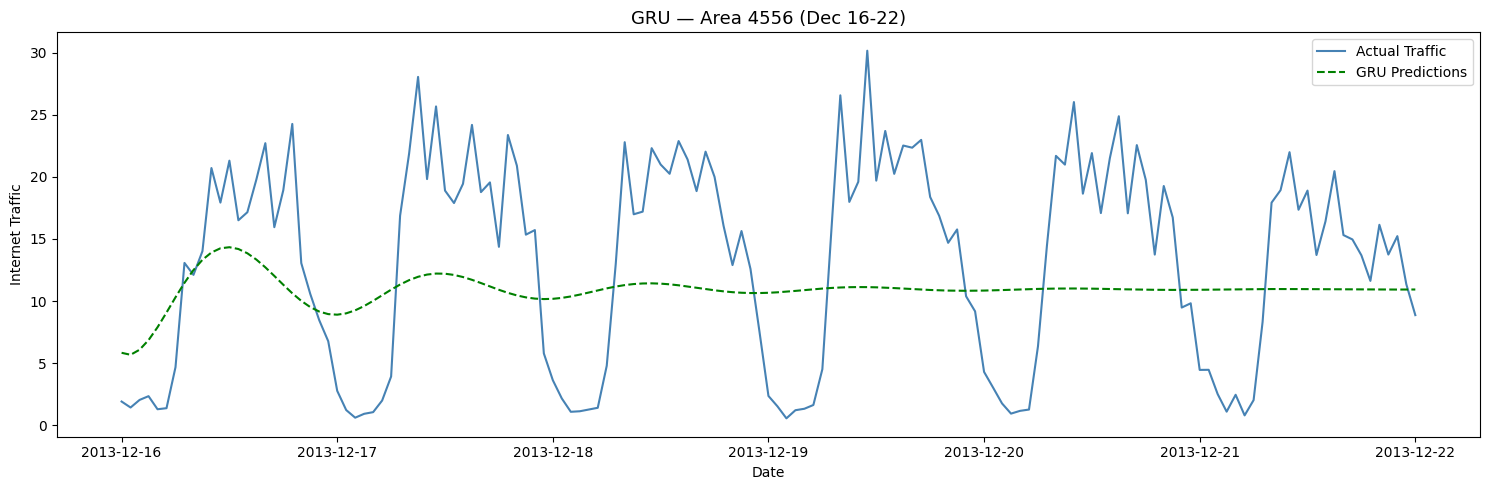

=== GRU METRICS ===
GRU — Area 5059:
  MAE:  15.2651
  MAPE: 310.32%
  RMSE: 17.4739
GRU — Area 4159:
  MAE:  2.9390
  MAPE: 612.25%
  RMSE: 3.4200
GRU — Area 4556:
  MAE:  7.1263
  MAPE: 181.09%
  RMSE: 7.9838


In [29]:
# Plot GRU predictions
plot_predictions(test1, pred_gru1, area1, 'GRU', 'green')
plot_predictions(test2, pred_gru2, area2, 'GRU', 'green')
plot_predictions(test3, pred_gru3, area3, 'GRU', 'green')

# Metrics
print("=== GRU METRICS ===")
mae_g1, mape_g1, rmse_g1 = calculate_metrics(test1, pred_gru1, area1, 'GRU')
mae_g2, mape_g2, rmse_g2 = calculate_metrics(test2, pred_gru2, area2, 'GRU')
mae_g3, mape_g3, rmse_g3 = calculate_metrics(test3, pred_gru3, area3, 'GRU')

In [30]:
# Full comparison tables
print("=" * 60)
print(f"TABLE 1 — AREA {area1} (Highest Traffic)")
print("=" * 60)
print(f"{'Model':<10} {'MAE':>10} {'MAPE':>10} {'RMSE':>10}")
print("-" * 60)
print(f"{'SARIMA':<10} {mae_s1:>10.4f} {mape_s1:>9.2f}% {rmse_s1:>10.4f}")
print(f"{'LSTM':<10} {mae_l1:>10.4f} {mape_l1:>9.2f}% {rmse_l1:>10.4f}")
print(f"{'GRU':<10} {mae_g1:>10.4f} {mape_g1:>9.2f}% {rmse_g1:>10.4f}")

print(f"\n{'=' * 60}")
print(f"TABLE 2 — AREA {area2}")
print("=" * 60)
print(f"{'Model':<10} {'MAE':>10} {'MAPE':>10} {'RMSE':>10}")
print("-" * 60)
print(f"{'SARIMA':<10} {mae_s2:>10.4f} {mape_s2:>9.2f}% {rmse_s2:>10.4f}")
print(f"{'LSTM':<10} {mae_l2:>10.4f} {mape_l2:>9.2f}% {rmse_l2:>10.4f}")
print(f"{'GRU':<10} {mae_g2:>10.4f} {mape_g2:>9.2f}% {rmse_g2:>10.4f}")

print(f"\n{'=' * 60}")
print(f"TABLE 3 — AREA {area3}")
print("=" * 60)
print(f"{'Model':<10} {'MAE':>10} {'MAPE':>10} {'RMSE':>10}")
print("-" * 60)
print(f"{'SARIMA':<10} {mae_s3:>10.4f} {mape_s3:>9.2f}% {rmse_s3:>10.4f}")
print(f"{'LSTM':<10} {mae_l3:>10.4f} {mape_l3:>9.2f}% {rmse_l3:>10.4f}")
print(f"{'GRU':<10} {mae_g3:>10.4f} {mape_g3:>9.2f}% {rmse_g3:>10.4f}")

print(f"\n{'=' * 60}")
print("TRAINING TIME COMPARISON")
print("=" * 60)
print(f"{'Model':<10} {'Area 5059':>10} {'Area 4159':>10} {'Area 4556':>10} {'Average':>10}")
print("-" * 60)
print(f"{'SARIMA':<10} {time_sarima1:>9.1f}s {time_sarima2:>9.1f}s {time_sarima3:>9.1f}s {(time_sarima1+time_sarima2+time_sarima3)/3:>9.1f}s")
print(f"{'LSTM':<10} {time_lstm1:>9.1f}s {time_lstm2:>9.1f}s {time_lstm3:>9.1f}s {(time_lstm1+time_lstm2+time_lstm3)/3:>9.1f}s")
print(f"{'GRU':<10} {time_gru1:>9.1f}s {time_gru2:>9.1f}s {time_gru3:>9.1f}s {(time_gru1+time_gru2+time_gru3)/3:>9.1f}s")

TABLE 1 — AREA 5059 (Highest Traffic)
Model             MAE       MAPE       RMSE
------------------------------------------------------------
SARIMA         5.0868     33.27%     8.1920
LSTM           7.1305     60.25%     9.9721
GRU           15.2651    310.32%    17.4739

TABLE 2 — AREA 4159
Model             MAE       MAPE       RMSE
------------------------------------------------------------
SARIMA         1.2929     71.76%     1.8639
LSTM           3.0238    484.24%     3.5829
GRU            2.9390    612.25%     3.4200

TABLE 3 — AREA 4556
Model             MAE       MAPE       RMSE
------------------------------------------------------------
SARIMA         2.5146     26.82%     3.3942
LSTM           4.6147     75.39%     5.6221
GRU            7.1263    181.09%     7.9838

TRAINING TIME COMPARISON
Model       Area 5059  Area 4159  Area 4556    Average
------------------------------------------------------------
SARIMA           4.0s       4.6s       3.8s       4.1s
LSTM        

In [31]:
# Failure Analysis — where do models perform worst?
errors_sarima = np.abs(np.array(test1) - np.array(pred_sarima1))
worst_hours = test1.index[np.argsort(errors_sarima)[-10:]]

print("Top 10 worst prediction hours (SARIMA, Area 5059):")
for t in sorted(worst_hours):
    idx = list(test1.index).index(t)
    print(f"  {t} — Actual: {test1[t]:.2f}, Predicted: {pred_sarima1[idx]:.2f}, Error: {errors_sarima[idx]:.2f}")

Top 10 worst prediction hours (SARIMA, Area 5059):
  2013-12-16 09:00:00 — Actual: 57.17, Predicted: 33.94, Error: 23.23
  2013-12-16 10:00:00 — Actual: 52.40, Predicted: 34.28, Error: 18.12
  2013-12-16 11:00:00 — Actual: 54.95, Predicted: 36.89, Error: 18.07
  2013-12-17 08:00:00 — Actual: 48.57, Predicted: 30.31, Error: 18.26
  2013-12-18 08:00:00 — Actual: 47.13, Predicted: 30.40, Error: 16.72
  2013-12-18 10:00:00 — Actual: 69.98, Predicted: 35.22, Error: 34.76
  2013-12-18 11:00:00 — Actual: 56.09, Predicted: 37.97, Error: 18.12
  2013-12-18 12:00:00 — Actual: 74.60, Predicted: 38.49, Error: 36.10
  2013-12-19 09:00:00 — Actual: 56.21, Predicted: 34.93, Error: 21.28
  2013-12-20 08:00:00 — Actual: 47.76, Predicted: 30.41, Error: 17.35


In [35]:
import matplotlib
matplotlib.use('Agg')

# Save all plots
plot_predictions(test1, pred_sarima1, area1, 'SARIMA', 'red')
plot_predictions(test2, pred_sarima2, area2, 'SARIMA', 'red')
plot_predictions(test3, pred_sarima3, area3, 'SARIMA', 'red')
plot_predictions(test1, pred_lstm1, area1, 'LSTM', 'purple')
plot_predictions(test2, pred_lstm2, area2, 'LSTM', 'purple')
plot_predictions(test3, pred_lstm3, area3, 'LSTM', 'purple')
plot_predictions(test1, pred_gru1, area1, 'GRU', 'green')
plot_predictions(test2, pred_gru2, area2, 'GRU', 'green')
plot_predictions(test3, pred_gru3, area3, 'GRU', 'green')

print("All 9 plots saved!")

All 9 plots saved!
